# Figure. 4, S14 & S15

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import pandas as pd
from mpl_toolkits.basemap import Basemap
import cmocean
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import matplotlib.colors as colors
from mpl_toolkits.axes_grid1 import AxesGrid
from mpl_toolkits.basemap import Basemap


In [2]:
ds1 = xr.open_dataset('/media/athira/One Touch/final_datasets/Review/Data_Scripts/data/Hplus_cmip6_ensemble_ssp585.nc').squeeze()
ds2 = xr.open_dataset('/media/athira/One Touch/final_datasets/Review/Data_Scripts/data/Hplus_cmip6_ensemble_ssp245.nc').squeeze()
ds3 = xr.open_dataset('/media/athira/One Touch/final_datasets/Review/Data_Scripts/data/Hplus_cmip6_ensemble_ssp126.nc').squeeze()


In [5]:
lat_range = slice(-30, 30)  # Latitude range from -30 to 30
lon_range = slice(30, 120)  # Longitude range from 30 to 100

Hplus_Hist  = ds1.sel(lat=lat_range, lon=lon_range, time=slice('1985', '2014')).groupby('time.month').mean()

Hplus_NF = ds1.sel(lat=lat_range, lon=lon_range, time=slice('2015', '2040')).groupby('time.month').mean()
Hplus_MF = ds1.sel(lat=lat_range, lon=lon_range, time=slice('2041', '2070')).groupby('time.month').mean()
Hplus_FF = ds1.sel(lat=lat_range, lon=lon_range, time=slice('2071', '2100')).groupby('time.month').mean()

Hplus_Hist_245  = ds1.sel(lat=lat_range, lon=lon_range, time=slice('1985', '2014')).groupby('time.month').mean()
Hplus_NF_245 = ds2.sel(lat=lat_range, lon=lon_range, time=slice('2015', '2040')).groupby('time.month').mean()
Hplus_MF_245 = ds2.sel(lat=lat_range, lon=lon_range, time=slice('2041', '2070')).groupby('time.month').mean()
Hplus_FF_245 = ds2.sel(lat=lat_range, lon=lon_range, time=slice('2071', '2100')).groupby('time.month').mean()

Hplus_Hist_126  = ds1.sel(lat=lat_range, lon=lon_range, time=slice('1985', '2014')).groupby('time.month').mean()
Hplus_NF_126 = ds3.sel(lat=lat_range, lon=lon_range, time=slice('2015', '2040')).groupby('time.month').mean()
Hplus_MF_126  = ds3.sel(lat=lat_range, lon=lon_range, time=slice('2041', '2070')).groupby('time.month').mean()
Hplus_FF_126  = ds3.sel(lat=lat_range, lon=lon_range, time=slice('2071', '2100')).groupby('time.month').mean()

NF_diff = Hplus_NF - Hplus_Hist
MF_diff = Hplus_MF - Hplus_Hist
FF_diff = Hplus_FF - Hplus_Hist

NF_diff_245 = Hplus_NF_245 - Hplus_Hist_245
MF_diff_245 = Hplus_MF_245 - Hplus_Hist_245
FF_diff_245 = Hplus_FF_245 - Hplus_Hist_245

NF_diff_126 = Hplus_NF_126 - Hplus_Hist_126
MF_diff_126 = Hplus_MF_126 - Hplus_Hist_126
FF_diff_126 = Hplus_FF_126 - Hplus_Hist_126


NF_diff = (NF_diff/Hplus_Hist)*100
MF_diff = (MF_diff/Hplus_Hist)*100
FF_diff = (FF_diff/Hplus_Hist)*100

NF_diff_245 = (NF_diff_245/Hplus_Hist)*100
MF_diff_245 = (MF_diff_245/Hplus_Hist)*100
FF_diff_245 = (FF_diff_245/Hplus_Hist)*100

NF_diff_126 = (NF_diff_126/Hplus_Hist)*100
MF_diff_126 = (MF_diff_126/Hplus_Hist)*100
FF_diff_126 = (FF_diff_126/Hplus_Hist)*100

NF_diff = NF_diff.mean('month')
MF_diff = MF_diff.mean('month')
FF_diff = FF_diff.mean('month')

NF_diff_245 = NF_diff_245.mean('month')
MF_diff_245 = MF_diff_245.mean('month')
FF_diff_245 = FF_diff_245.mean('month')


NF_diff_126 = NF_diff_126.mean('month')
MF_diff_126 = MF_diff_126.mean('month')
FF_diff_126 = FF_diff_126.mean('month')

# Plot

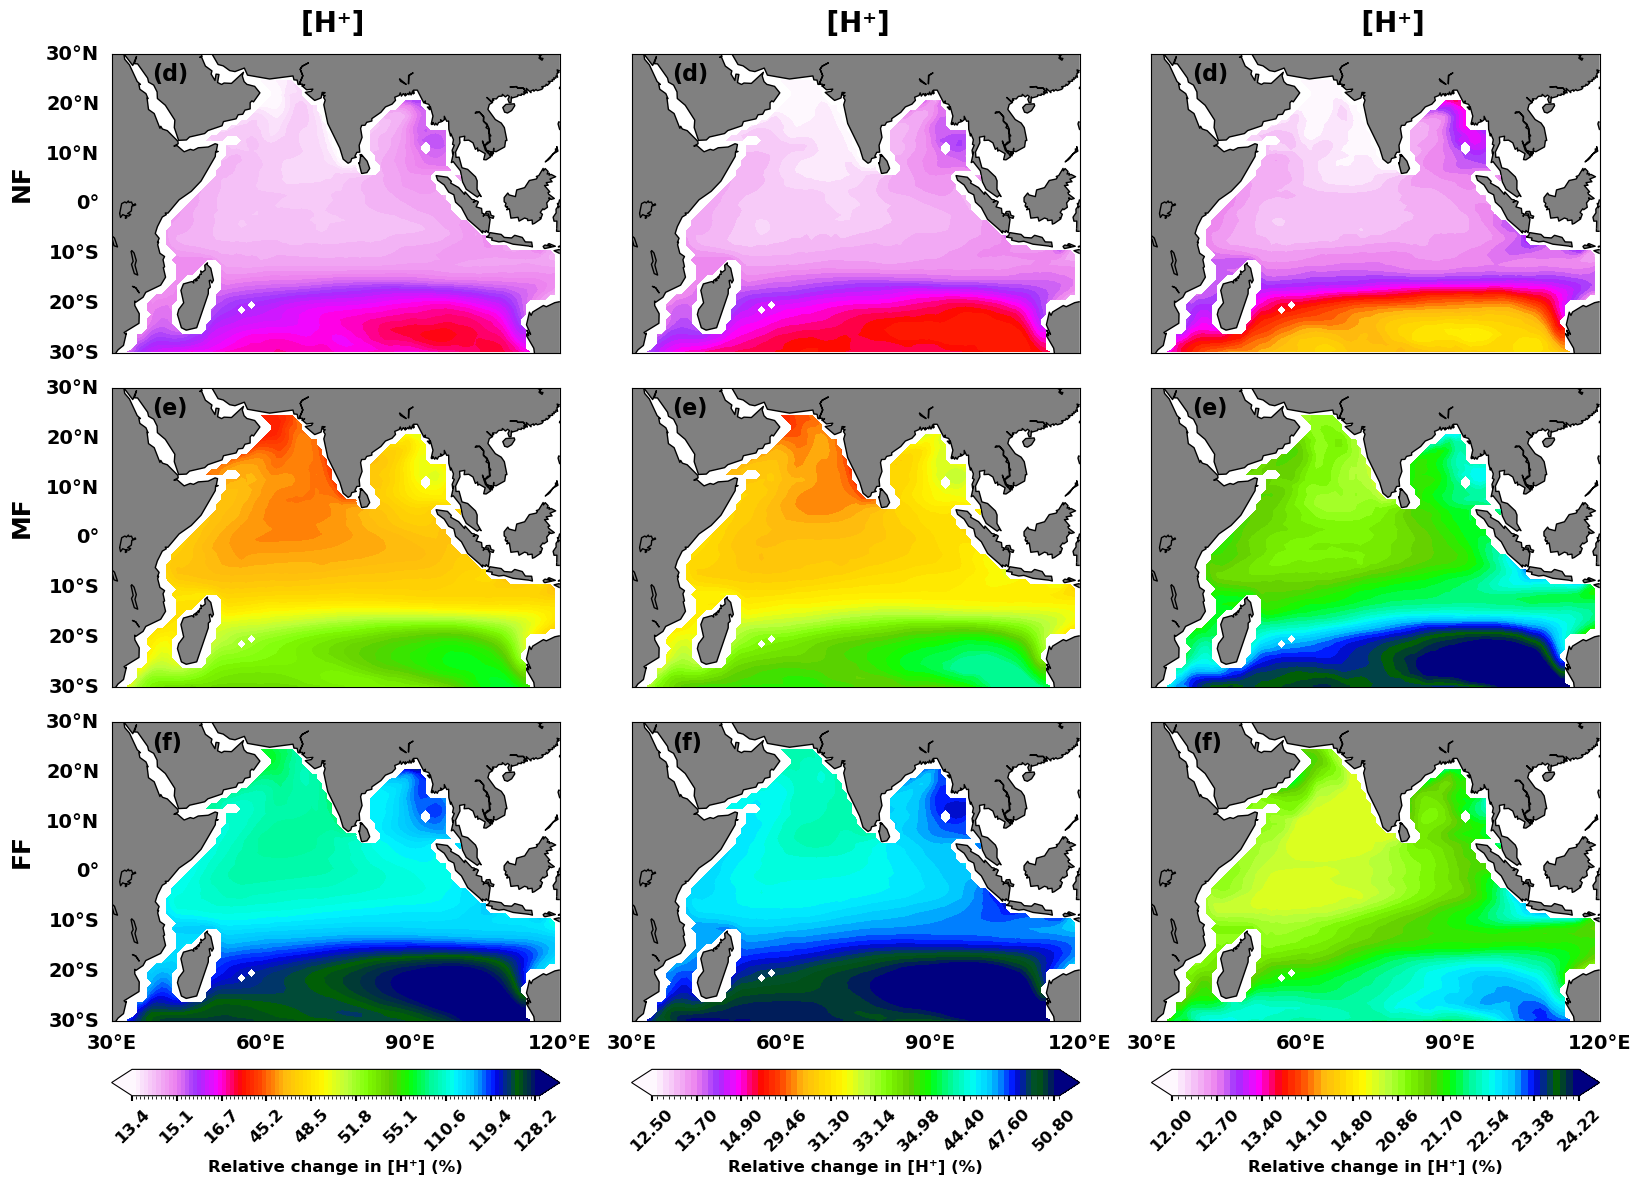

In [6]:

l1_diff = np.arange(13.4, 17.5, 0.15)
l2_diff = np.arange(17.5, 44, 27)
l3_diff = np.arange(44, 56, 0.3)
l4_diff = np.arange(56, 105, 55)
l5_diff = np.arange(105, 129.4, 0.8)


l6_diff = np.concatenate((l1_diff, l2_diff, l3_diff, l4_diff, l5_diff))
norm_diff = colors.BoundaryNorm(l6_diff, ncolors=256)


l1_diff_245 = np.arange(12.5, 15.5, 0.15)
l2_diff_245 = np.arange(15.5, 29, 13)
l3_diff_245 = np.arange(29, 36, 0.23)
l4_diff_245 = np.arange(36, 44, 7)
l5_diff_245 = np.arange(44, 51.2, 0.4)


l6_diff_245 = np.concatenate((l1_diff_245, l2_diff_245, l3_diff_245, l4_diff_245, l5_diff_245))
norm_diff_245 = colors.BoundaryNorm(l6_diff_245, ncolors=256)


l1_diff_126 = np.arange(12, 15, 0.1)
l2_diff_126 = np.arange(15, 20.5, 5)
l3_diff_126 = np.arange(20.5, 24.3, 0.12)
# l4_diff_126 = np.arange(-0.060, -0.048, 0.0006)

l4_diff_126 = np.concatenate((l1_diff_126, l2_diff_126, l3_diff_126))
norm_diff_126 = colors.BoundaryNorm(l4_diff_126, ncolors=256)


fig, ax = plt.subplots(nrows=3, ncols=3, sharex=True, sharey=True, figsize=(24, 20))
plt.subplots_adjust(bottom=0.2, top=0.8, left=0.13, right=0.75, wspace=0.16, hspace=0.1)
fig.suptitle('[H⁺]                                                [H⁺]                                                 [H⁺]', fontsize=20, ha= 'center', fontweight='bold',x=0.443,y=0.82)
 

# subplot_labels = ['(a)', '(d)', '(g)', '(b)', '(e)', '(h)', '(c)', '(f)', '(i)']
subplot_labels = ['(d)', '(d)', '(d)', '(e)', '(e)', '(e)', '(f)', '(f)', '(f)']


periods = ['NF', 'MF', 'FF']

datasets = {
    'Hplus': [NF_diff, MF_diff, FF_diff],
    'Hplus_245': [NF_diff_245, MF_diff_245, FF_diff_245],
    'Hplus_126': [NF_diff_126, MF_diff_126, FF_diff_126]
}

quad_contour_sets_Hplus = []
quad_contour_sets_Hplus_245 = []
quad_contour_sets_Hplus_126 = []
for i, period in enumerate(periods):
    for j, (key, data_list) in enumerate(datasets.items()):
        data = data_list[i]
        Hplus_data = np.squeeze(data.Hplus)

        if key == 'Hplus':
            norm = norm_diff
            cmap1 = 'gist_ncar_r'
            levels = l6_diff  
        elif key =='Hplus_245':
            norm = norm_diff_245
            cmap1 = 'gist_ncar_r'
            levels = l6_diff_245
        else:  #'Hplus_126'
            norm = norm_diff_126
            cmap1 = 'gist_ncar_r'
            levels = l4_diff_126
            
        m = Basemap(llcrnrlat=-30.1, urcrnrlat=30.1, llcrnrlon=30, urcrnrlon=120.1, resolution='c', ax=ax[i, j])
        m.drawcoastlines()
        m.fillcontinents(color='gray', lake_color='gray')

        ax[i, j].tick_params(axis='both', which='major', labelsize=6, width=0.8, length=3)
        ax[i, j].set_axisbelow(True)

        lon, lat = np.meshgrid(data.lon, data.lat)

        if key == 'Hplus':
            quad_contour_set = m.contourf(lon, lat, Hplus_data, levels = l6_diff, norm = norm_diff, cmap=cmap1, zorder=10, extend='both')

            quad_contour_sets_Hplus.append(quad_contour_set)
        elif key == 'Hplus_245':
            quad_contour_set = m.contourf(lon, lat, Hplus_data, levels = l6_diff_245, norm = norm_diff_245, cmap=cmap1, zorder=10, extend='both')
            quad_contour_sets_Hplus_245.append(quad_contour_set)
        else:
            quad_contour_set = m.contourf(lon, lat, Hplus_data, levels = l4_diff_126, norm = norm_diff_126, cmap=cmap1, zorder=10, extend='both')
            quad_contour_sets_Hplus_126.append(quad_contour_set)

for i in range(3):
    m = Basemap(llcrnrlat=-30.1, urcrnrlat=30.1, llcrnrlon=30, urcrnrlon=120.1, resolution='c', ax=ax[i, 0])
    m.drawparallels(range(-30, 31, 10), labels=[1, 0, 0, 1], color='w', fontsize=14, fontweight='bold', zorder=0, xoffset=2.5)

for j in range(3):
    m = Basemap(llcrnrlat=-30.1, urcrnrlat=30.1, llcrnrlon=30, urcrnrlon=120.1, resolution='c', ax=ax[2, j])
    m.drawmeridians(range(30, 121, 30), labels=[1, 0, 0, 1], color='w', fontsize=14, fontweight='bold', zorder=0, yoffset=2.5)

for i, period in enumerate(periods):
    ax[i, 0].text(-0.2, 0.57, f"{period}", horizontalalignment='center', verticalalignment='center',
                  rotation='vertical', fontsize=18, fontweight='bold', c='k', transform=ax[i, 0].transAxes, zorder=10)

for i in range(3):
    for j in range(3):
        idx = i * 3 + j
        ax[i, j].text(0.09, 0.97, subplot_labels[idx], transform=ax[i, j].transAxes, fontsize=16, fontweight='bold', 
                      va='top', ha='left', color='k')    

# cbar_num_format = "%.3f"    
    
cbar1 = fig.colorbar(quad_contour_sets_Hplus[0], ax=ax[:, 0], pad=0.04, shrink=1, aspect=17, orientation='horizontal', extend='both')#, format=cbar_num_format)#, ticks=(7.710, 7.805, 7.900, 7.995, 8.090))
cbar1.ax.tick_params(labelsize=12, width=1.5, rotation=45)
cbar1.set_label('Relative change in [H⁺] (%)', fontsize=12, fontweight='bold')
for label in cbar1.ax.get_xticklabels():
    label.set_fontweight('bold')

#colorbar
cbar2 = fig.colorbar(quad_contour_sets_Hplus_245[0], ax=ax[:, 1], pad=0.04, shrink=1, aspect=17, orientation='horizontal', extend='both')#, format=cbar_num_format)#, ticks=(-0.30, -0.20, -0.10))
cbar2.ax.tick_params(labelsize=12, width=1.5, rotation=45)
cbar2.set_label('Relative change in [H⁺] (%)', fontsize=12, fontweight='bold')

for label in cbar2.ax.get_xticklabels():
    label.set_fontweight('bold')
    
cbar3 = fig.colorbar(quad_contour_sets_Hplus_126[0], ax=ax[:, 2], pad=0.04, shrink=1, aspect=17, orientation='horizontal', extend='both')#, format=cbar_num_format)#, ticks=(-0.30, -0.20, -0.10))
cbar3.ax.tick_params(labelsize=12, width=1.5, rotation=45)
cbar3.set_label('Relative change in [H⁺] (%)', fontsize=12, fontweight='bold')
for label in cbar3.ax.get_xticklabels():
    label.set_fontweight('bold')
# plt.savefig('H+_mean_change_Review_f2.png', bbox_inches = 'tight', dpi = 300)


plt.show()